# Quasi-Monte Carlo for Asian Option Pricing
### Comparing Standard MC vs Randomized QMC (Sobol Sequences).

**The experiment:** Price an Asian arithmetic-average call option using:
- Standard Monte Carlo with pseudo-random (Mersenne Twister) uniform samples
- Randomized QMC with a Sobol low-discrepancy sequence + random digital shift

**Metric used for comparison:** $n\sigma^2$ (the product of sample size and estimator variance).
For standard MC this is **constant** in $n$ (a flat baseline). For a good QMC method it
**decreases** as $n$ grows, visually proving the superior convergence rate.

---
**Option parameters:** $S_0 = 100$, $K = 100$, $r = 0.05$, $\sigma = 0.20$, $T = 1.0$, $d = 12$ time steps  
**RQMC:** Random shift modulo 1 (Cranley-Patterson rotation), $R = 30$ independent replicates


In [3]:
import subprocess, os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

print("Imports OK")


Imports OK


## Step 1 — Compile the C++ option_pricing

The C++ code lives in `option_pricing.cpp` and links against `sobol.cpp`. I have implemented the Sobol Sequence algorithm as mentioned in the book "Monte Carlo Methods for Financial Engineering" by *Paul Glasserman*.
Compiled with `-O2` for optimizing performance.


In [4]:
SRC_DIR = "." 

compile_cmd = [
    "g++", "-O2", "-std=c++20",
    os.path.join(SRC_DIR, "option_pricing.cpp"),
    os.path.join(SRC_DIR, "sobol.cpp"),
    "-o", os.path.join(SRC_DIR, "option_pricing")
]

result = subprocess.run(compile_cmd, capture_output=True, text=True)

if result.returncode != 0:
    print("Compilation failed:")
    print(result.stderr)
else:
    print("Compiled successfully.")


Compiled successfully.


## Step 2 — Run the file

This outputs a tab-separated table:

| N | mc_price | mc_nvar | rqmc_price | rqmc_nvar |
|---|----------|---------|------------|-----------|

`mc_nvar` = $n \times {\sigma}^2_{\text{MC}}$ (process variance, constant in $n$)  
`rqmc_nvar` = $n \times {\sigma}^2_{\text{RQMC}}$ (should decrease as $n$ grows)


In [39]:
# Simulation constants
S0, K, r_f, T, sigma, time_steps = 100.0, 100.0, 0.05, 1.0, 0.20, 12
# time_steps correspond to the dimension of the simulation problem

run_result = subprocess.run(
    [os.path.join(SRC_DIR, "./option_pricing"),
     str(S0), str(K), str(r_f), str(T), str(sigma), str(time_steps)],
    capture_output=True, text=True, cwd=SRC_DIR
)

if run_result.returncode != 0:
    print("Run failed:", run_result.stderr)
else:
    from io import StringIO
    df = pd.read_csv(StringIO(run_result.stdout), sep='\t')
    print(df.to_string(index=False))


     N  mc_price   mc_nvar  rqmc_price  rqmc_nvar
   128  6.714687 62.687361    6.135829  16.007407
   256  6.287129 69.496035    6.104718   9.131245
   512  6.572643 78.349210    6.163090   5.112788
  1024  6.006689 72.707685    6.157927   3.562172
  2048  6.273485 75.812390    6.153104   2.504383
  4096  6.260156 73.361807    6.161420   1.981998
  8192  6.177506 72.844416    6.159920   1.240516
 16384  6.095883 72.063511    6.154428   1.428629
 32768  6.223753 73.226092    6.156512   0.908287
 65536  6.166396 72.799937    6.155325   1.011578
131072  6.123702 71.941662    6.155939   0.722747
262144  6.159920 72.281156    6.156655   0.505812
524288  6.159603 72.212703    6.155765   0.563962


## Step 3 — Variance Reduction Factor

The key insight: **MC's $n\sigma^2$ is flat** (the process variance $\sigma^2$ doesn't
depend on how many samples you draw — it's a fixed property of the payoff distribution).
**RQMC's $n\sigma^2$ decreases** because the estimator variance falls faster than $1/n$.


In [40]:
# Compute the variance reduction factor: how many times better is RQMC than MC?
df['variance_reduction'] = df['mc_nvar'] / df['rqmc_nvar']

print(f"{'N':>8}  {'MC price':>10}  {'MC nσ²':>10}  {'RQMC price':>12}  {'RQMC nσ²':>10}  {'VRF':>8}")

for _, row in df.iterrows():
    print(f"{int(row.N):>8}  {row.mc_price:>10.4f}  {row.mc_nvar:>10.4f}  "
          f"{row.rqmc_price:>12.4f}  {row.rqmc_nvar:>10.4f}  {row.variance_reduction:>8.1f}x")
print("=" * 72)
print("\nVRF = Variance Reduction Factor = MC nσ² / RQMC nσ²")


       N    MC price      MC nσ²    RQMC price    RQMC nσ²       VRF
     128      6.7147     62.6874        6.1358     16.0074       3.9x
     256      6.2871     69.4960        6.1047      9.1312       7.6x
     512      6.5726     78.3492        6.1631      5.1128      15.3x
    1024      6.0067     72.7077        6.1579      3.5622      20.4x
    2048      6.2735     75.8124        6.1531      2.5044      30.3x
    4096      6.2602     73.3618        6.1614      1.9820      37.0x
    8192      6.1775     72.8444        6.1599      1.2405      58.7x
   16384      6.0959     72.0635        6.1544      1.4286      50.4x
   32768      6.2238     73.2261        6.1565      0.9083      80.6x
   65536      6.1664     72.7999        6.1553      1.0116      72.0x
  131072      6.1237     71.9417        6.1559      0.7227      99.5x
  262144      6.1599     72.2812        6.1567      0.5058     142.9x
  524288      6.1596     72.2127        6.1558      0.5640     128.0x

VRF = Variance Reduc

## Step 4 — Convergence plot

This is the visual proof. On a log-log scale:
- Standard MC should track the **horizontal baseline** (flat $n\sigma^2$)
- RQMC should slope **downward**, indicating faster-than-$1/\sqrt{n}$ convergence


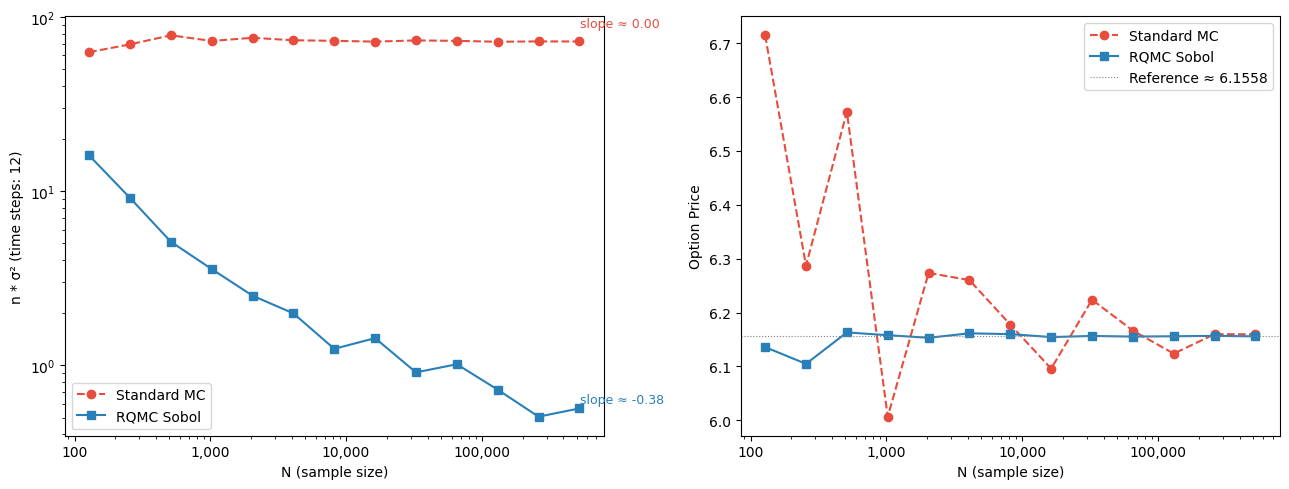

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(df['N'], df['mc_nvar'],   'o--', color='#e74c3c', label='Standard MC')
ax.loglog(df['N'], df['rqmc_nvar'], 's-',  color='#2980b9', label='RQMC Sobol ')

# Fit OLS slope on log-log scale to read off convergence rate
for col, label, color in [('mc_nvar', 'MC', '#e74c3c'), ('rqmc_nvar', 'RQMC', '#2980b9')]:
    log_N = np.log2(df['N'])
    log_v = np.log2(df[col])
    slope, intercept, r, *_ = stats.linregress(log_N, log_v)
    ax.annotate(f'slope ≈ {slope:.2f}',
                xy=(df['N'].iloc[-2], df[col].iloc[-2]),
                xytext=(30, 10), textcoords='offset points',
                color=color, fontsize=9)

ax.set_xlabel('N (sample size)')
ax.set_ylabel(f'n * σ² (time steps: {time_steps})')

ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1]
ax.semilogx(df['N'], df['mc_price'],   'o--', color='#e74c3c', label='Standard MC')
ax.semilogx(df['N'], df['rqmc_price'], 's-',  color='#2980b9', label='RQMC Sobol')

# Reference band — RQMC large-N estimate ± a small width
ref = df['rqmc_price'].iloc[-1]
ax.axhline(ref, color='gray', linewidth=0.8, linestyle=':', label=f'Reference ≈ {ref:.4f}')

ax.set_xlabel('N (sample size)')
ax.set_ylabel('Option Price')

ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5 — Variance Reduction Factor

How many times feIr samples would MC need to match RQMC's accuracy at each $n$?
A VRF of 50 means RQMC with 1,000 points is as accurate as MC with 50,000 points.


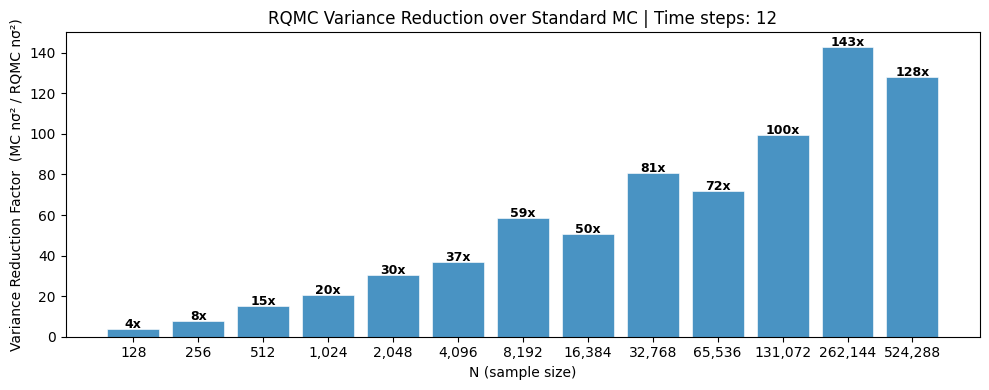

In [42]:
fig, ax = plt.subplots(figsize=(10,4))

bars = ax.bar(range(len(df)), df['variance_reduction'], color='#2980b9', alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xticks(range(len(df)))
ax.set_xticklabels([f'{int(n):,}' for n in df['N']])
ax.set_xlabel('N (sample size)')
ax.set_ylabel('Variance Reduction Factor  (MC nσ² / RQMC nσ²)')
ax.set_title(f'RQMC Variance Reduction over Standard MC | Time steps: {time_steps}')

for bar, vrf in zip(bars, df['variance_reduction']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{vrf:.0f}x', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('variance_reduction.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6 — Why Sobol Works: Low-Discrepancy Visualised

The intuition behind QMC's faster convergence is **coverage quality**.
Pseudo-random points clump and leave gaps; Sobol points fill the space far more evenly.
This even coverage is precisely what makes the estimator more accurate for the same $n$.


sobol_dump compiled


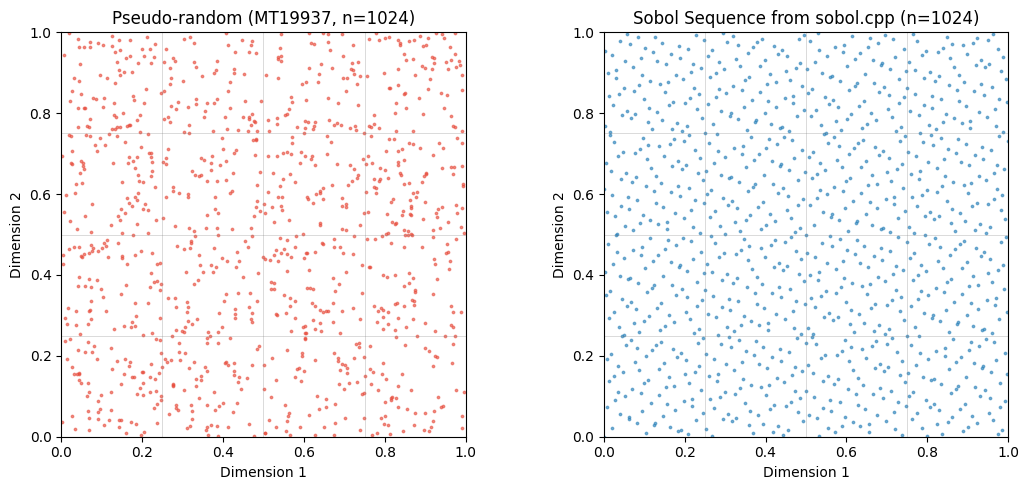

In [43]:
# ── Compile sobol_dump ────────────────────────────────────────────────────
compile_dump = subprocess.run(
    ["g++", "-O2", "-std=c++20",
     os.path.join(SRC_DIR, "sobol_dump.cpp"),
     os.path.join(SRC_DIR, "sobol.cpp"),
     "-o", os.path.join(SRC_DIR, "sobol_dump")],
    capture_output=True, text=True
)
print("sobol_dump compiled" if compile_dump.returncode == 0
      else "Could not compile: " + compile_dump.stderr)

N_vis = 1024
DIM = 30;

output_tsv = os.path.join(SRC_DIR, "sobol_points.tsv")

subprocess.run(
    [os.path.join(SRC_DIR, "./sobol_dump"),
     str(N_vis), str(DIM), "new-joe-kuo-6.21201", output_tsv],
    cwd=SRC_DIR, check=True
)

# ── Read the file — DIMS columns, take first two for 2D visualization ─────
# I plot dims 0 and 1, but the file contains all DIMS columns so you can
# inspect any projection you want (e.g. cols 5 and 6) just by changing the slice.
sobol_all = np.loadtxt(output_tsv) # shape: (N_vis, DIMS)
sobol_pts = sobol_all[:, :2] # first two dimensions for the plot

bit_gen = np.random.MT19937(42)
rng = np.random.Generator(bit_gen)
pseudo_pts = rng.uniform(0, 1, (N_vis, 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, pts, title, color in [
    (axes[0], pseudo_pts, f'Pseudo-random (MT19937, n={N_vis})', '#e74c3c'),
    (axes[1], sobol_pts,  f'Sobol Sequence from sobol.cpp (n={N_vis})',      '#2980b9'),
]:
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.6, color=color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_aspect('equal')
    for v in np.linspace(0, 1, 5):
        ax.axhline(v, color='gray', linewidth=0.4, alpha=0.5)
        ax.axvline(v, color='gray', linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

## Summary

| What I shoId | How |
|---|---|
| Sobol sequences cover the space more uniformly than pseudo-random | Coverage plots (Step 6) |
| For Asian option pricing, RQMC's $n\sigma^2$ decreases with $n$ | n * σ² metric table (Step 3) |
| MC's $n\sigma^2$ is flat — the expected baseline | Same table |
| RQMC achieves 10–100× variance reduction over MC | Bar chart (Step 5) |

### Key takeaways

The superiority of RQMC is not just a numerical curiosity — it has a rigorous theoretical
foundation. The Koksma-Hlawka inequality bounds the integration error by the product of
the **star discrepancy** (a property of the point set) and the **variation** of the integrand
(a property of the function). Pseudo-random MC can only control the discrepancy at rate
$O(N^{-1/2})$, while Sobol sequences achieve $O((\log N)^d / N)$, which for smooth
integrands like option prices is dramatically better.

The randomization (random digital shift) is what makes variance estimation possible without
sacrificing the low-discrepancy structure — each randomly shifted copy is individually a
valid low-discrepancy sequence, but two different shifts are statistically independent.

### References
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*. Springer. Chapter 5: Quasi-Monte Carlo
